# Screening, end to end

The pipeline matverse exists for: take a list of candidate structures, remove
the ones that are broken, relax what remains, work out which are
thermodynamically plausible, and shortlist — keeping the reasoning attached to
the object rather than in your head.

Everything here runs on `emt`, ASE's effective-medium theory, which ships with
ASE and needs no download. The library is the Al–Ni–Cu system: three elemental
metals from published lattice parameters, plus hypothetical ordered
intermetallics built on the L1₂ prototype — the [Cu₃Au
structure](https://doi.org/10.1103/PhysRev.49.122) that most fcc-based ordered
alloys adopt.

The elementals are real; the intermetallics are candidates. That is what a
screen looks like.

In [1]:
import matverse as mv
import numpy as np

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 213   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Build a dataset

`mv.datasets.metals` gives the elemental fcc metals at their measured
room-temperature lattice parameters.

In [2]:
elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
elemental.obs[["name", "lattice_parameter"]]

,name,lattice_parameter
0,Al,4.0495
1,Cu,3.6149
2,Ni,3.5240


The candidates are L1₂ orderings of the same three elements, plus a B2 AlNi.
Both prototypes are built by hand, because that is what a candidate is — a
structure nobody has computed yet.

In [3]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    """Cu3Au prototype: guest on the corner, host on the faces."""
    return Structure(Lattice.cubic(a),
                     [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


def b2(a_symbol, b_symbol, a):
    """CsCl prototype."""
    return Structure(Lattice.cubic(a), [a_symbol, b_symbol],
                     [[0, 0, 0], [.5, .5, .5]])


candidates = [
    l12("Al", "Cu", 3.90),      # Al3Cu
    l12("Cu", "Al", 3.70),      # AlCu3
    l12("Al", "Ni", 3.78),      # Al3Ni
    b2("Al", "Ni", 2.89),       # AlNi
]

Put the published elementals and the candidates into one object. Building it in
a single call keeps the row names sequential, which matters more than it sounds
— every later table is indexed by them.

In [4]:
md = mv.data.from_structures(mv.structures(elemental) + candidates)
md

AnnData object with n_obs × n_vars = 7 × 3
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is'
    obsm: 'structures'
    layers: None (.X)

Seven materials, three elements. `X` is already the composition matrix and `var`
is already the periodic table restricted to Al, Ni and Cu — you did not ask for
either, because composition is intrinsic to a material rather than derived from
it.

In practice you would load from disk or from a database instead:

```python
md = mv.data.from_cif('candidates/')
md = mv.data.from_mp({'elements': ['Al', 'Ni'], 'num_elements': (2, 2)})
```

## Standardise and describe

In [5]:
mv.pp.standardize(md)      # primitive + conventional + spacegroup
mv.pp.describe(md)         # formula, nsites, volume, density, n_elements

md.obs[["formula", "spacegroup", "n_elements"]]

,formula,spacegroup,n_elements
0,Al,Fm-3m,1
1,Cu,Fm-3m,1
2,Ni,Fm-3m,1
3,Al3Cu,Pm-3m,2
4,AlCu3,Pm-3m,2
5,Al3Ni,Pm-3m,2
6,AlNi,Pm-3m,2


`standardize` deposits two new structure variants rather than replacing the
input. Every later call names which one it wants.

In [6]:
mv.variants(md)

['input', 'primitive', 'conventional']

## Throw out what is broken

`qc` is the analogue of `scanpy.pp.calculate_qc_metrics`, and it exists for the
same reason: a generated or database structure with atoms 0.1 Å apart is a
broken cell, not an exotic one. Relaxing it wastes the calculator's time and
pollutes the hull.

In [7]:
mv.pp.qc(md)
md.obs[["formula", "min_distance", "is_ordered", "is_valid", "qc_reason"]]

,formula,min_distance,is_ordered,is_valid,qc_reason
0,Al,2.863429,True,True,
1,Cu,2.556120,True,True,
2,Ni,2.491844,True,True,
3,Al3Cu,2.757716,True,True,
4,AlCu3,2.616295,True,True,
5,Al3Ni,2.672864,True,True,
6,AlNi,2.502813,True,True,


In [8]:
md = mv.pp.filter_materials(md)
mv.provenance(md)[-1]

"pp.filter_materials(flag='is_valid', n_dropped=0)"

This is one of the few calls that returns instead of depositing, because AnnData
cannot drop rows in place — and it records how many it dropped.

Duplicates are worth removing before you spend compute on them twice:

In [9]:
mv.pp.dedup(md)
md.uns["dedup"]

{'source': 'input',
 'n_blocks': 7,
 'n_duplicates': 0,
 'n_unique': 7,
 'matcher': {'ltol': 0.2, 'stol': 0.3, 'angle_tol': 5.0},
 'n_comparison_failures': 0}

`dedup` blocks on `(reduced formula, space group)` before running pymatgen's
`StructureMatcher` inside each block. An all-pairs comparison is quadratic and
unusable past a few thousand candidates; blocking makes the expensive part
local.

## Relax

In [10]:
mv.calc.relax(md, level="emt", fmax=0.05)

md.obs[["formula", "energy_emt", "energy_per_atom_emt",
        "relax_converged_emt"]].round(4)

,formula,energy_emt,energy_per_atom_emt,relax_converged_emt
0,Al,-0.0195,-0.0049,True
1,Cu,-0.0281,-0.0070,True
2,Ni,-0.0532,-0.0133,True
3,Al3Cu,0.3115,0.0779,True
4,AlCu3,0.4350,0.1087,True
5,Al3Ni,0.6185,0.1546,True
6,AlNi,0.6772,0.3386,True


The relaxed geometry becomes its own variant, `relaxed_emt`, rather than
overwriting the input — so "which structure was this energy computed on" stays
answerable from the object alone.

The level records what produced it:

In [11]:
mv.level_info(md, "emt")

{'kind': 'classical',
 'method': 'EMT',
 'reference': None,
 'surrogate': True,
 'license': 'LGPL-2.1',
 'uncertainty': None,
 'note': 'ASE effective-medium theory. Parameterised only for Al Cu Ag Au Ni Pd Pt H C N O — enough to exercise a pipeline, not enough to screen with.',
 'source': 'input',
 'fmax': 0.05,
 'steps': 200,
 'cell': True,
 'n_failed': 0}

`surrogate: True` and `license: 'LGPL-2.1'` are not decoration. The first is
what `mv.thermo.hull` checks before it agrees to mix two levels; the second is
what `mv.calc.check_licenses` reads when you need to know whether a result can
go in a commercial report.

## Build a hull

In [12]:
mv.thermo.hull(md, level="emt", source="relaxed_emt")

md.obs[["formula", "e_above_hull_emt", "is_stable_emt",
        "decomposes_to_emt"]].round(4)

,formula,e_above_hull_emt,is_stable_emt,decomposes_to_emt
0,Al,0.0000,True,Al:1.00
1,Cu,0.0000,True,Cu:1.00
2,Ni,0.0000,True,Ni:1.00
3,Al3Cu,0.0833,False,Al:0.75 + Cu:0.25
4,AlCu3,0.1152,False,Cu:0.75 + Al:0.25
5,Al3Ni,0.1616,False,Al:0.75 + Ni:0.25
6,AlNi,0.3477,False,Al:0.50 + Ni:0.50


```{warning}
That call emitted a warning, and you should read it. With no `references=`, the
hull is built over **this dataset's own compositions**, which makes
`e_above_hull` a statement about which of your candidates is lowest — not about
whether any of them is stable. Screening 40 generated oxides against each other
will happily report several as "on the hull" when all 40 decompose.
```

Two things about this particular table are worth saying plainly rather than
leaving for a reader to trip over.

EMT's energy zero is the pure element at its equilibrium lattice constant, so
the elemental energies come out at essentially zero and every intermetallic is
positive by construction. **This hull cannot find a stable alloy.** It is
demonstrating the pipeline, not the Al–Ni–Cu phase diagram.

And Al₃Ni is a real, stable phase — it just is not the L1₂ polymorph built
above; the observed one is orthorhombic. A number attached to a prototype says
nothing about a compound that adopts a different structure. Both of those are
ordinary screening mistakes, and both are visible here because the level of
theory and the structure variant are recorded rather than assumed.

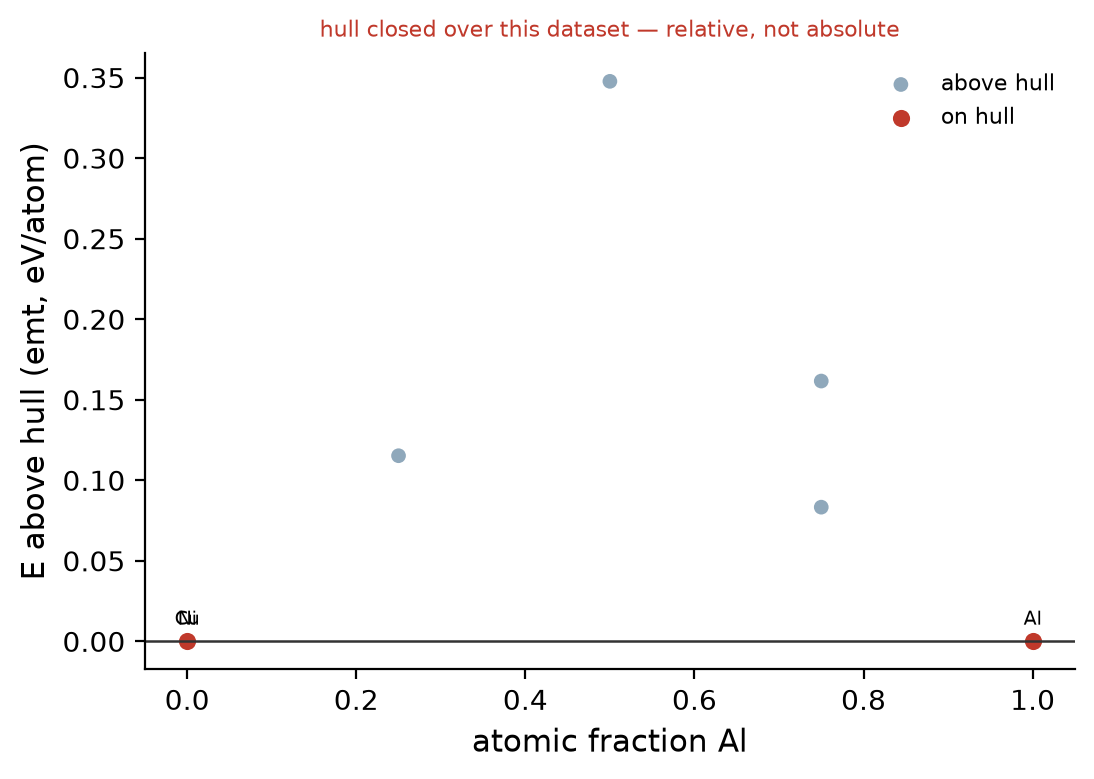

In [13]:
ax = mv.pl.hull(md, level="emt", x="Al")

The hull plot labels itself when the hull is closed, because a convex hull drawn
without its competing phases looks identical to one drawn with them and means
something entirely different.

Formation energy against composition is also the plot that makes the previous
paragraph obvious: the two elemental endpoints sit at zero and everything
between them is above the tie-line.

In [14]:
md.uns["phase_diagram"]["closed_system"]

True

The object records which kind of number you have, so a later reader does not
have to guess.

To make it absolute, pass the known competing phases:

```python
refs = mv.thermo.references_from_mp(['Al', 'Ni', 'Cu'])   # needs mp-api
mv.thermo.hull(md, level='pbe', references=refs)
```

Note the level changed. Materials Project entries are PBE+U with fitted
corrections; putting them on a hull with EMT energies is not a hull of anything,
and `mv.thermo.hull` raises `LevelMismatch` rather than letting you.

### The corrections, when the energies are your own

"With fitted corrections" is doing a lot of work in that sentence. An energy
that came back from your own VASP run has **not** been corrected, and putting it
on a hull beside Materials Project entries that have been is the same class of
error as mixing EMT with PBE — except that nothing about the column names says
so.

`mv.thermo.corrections` applies the published scheme and deposits the result as
its own level, so the two can never be the same column.

In [15]:
from pymatgen.core import Lattice, Structure

def cell(symbols):
    return Structure(Lattice.cubic(5.0), symbols,
                     [[0, 0, 0], [.5, .5, .5], [.25, .25, .25],
                      [.5, 0, 0], [0, .5, 0]][:len(symbols)])

oxides = mv.data.from_structures([cell(["Fe", "Fe", "O", "O", "O"]),
                                  cell(["Al", "Al", "O", "O", "O"]),
                                  cell(["Cu", "Cu"])])
mv.pp.describe(oxides)
oxides.obs["energy_pbe"] = [-50.0, -60.0, -10.0]      # as if read from VASP

mv.thermo.corrections(oxides, level="pbe")
oxides.obs[["formula", "energy_pbe", "energy_pbe-mp2020",
            "correction_pbe-mp2020", "run_type_pbe-mp2020"]].round(3)

,formula,energy_pbe,energy_pbe-mp2020,correction_pbe-mp2020,run_type_pbe-mp2020
0,Fe2O3,-50.0,-56.573,-6.573,GGA+U
1,Al2O3,-60.0,-62.061,-2.061,GGA
2,Cu,-10.0,-10.000,0.000,GGA


Three rows, three different answers, none of them small.

**Al₂O₃** gets −2.06 eV, which is exactly 3 × −0.687 — the oxide anion
correction, once per oxygen. It fixes the known overbinding of the O₂ molecule
that a formation energy is referenced against.

**Fe₂O₃** gets −6.57 eV. The extra 4.5 eV is the +U correction on two irons, and
it applies because MP would have run this calculation as GGA+U. `run_type` is
inferred by MP's own rule — a transition metal from its table together with
oxygen or fluorine — and recorded, rather than assumed.

**Cu** gets nothing. An elemental metal has no anion to correct and no U.

For scale: 6.6 eV per formula unit against the ~0.05 eV/atom threshold a screen
calls "close to the hull". A hull built on the uncorrected column would not be
slightly wrong.

The corrected energy is `energy_pbe-mp2020`, not `energy_pbe`. That is the
level-of-theory rule applied one step further along: a corrected energy is a
different quantity, so it gets a different name and its own entry in
`uns['levels']` recording what was done to it.

In [16]:
mv.level_info(oxides, "pbe-mp2020")

{'kind': 'corrected',
 'method': 'Materials Project 2020 corrections',
 'reference': 'pbe',
 'surrogate': False,
 'license': None,
 'uncertainty': None,
 'scheme': 'mp2020',
 'corrected_from': 'pbe'}

### What it would cost, and whether you could get it

Two screening axes that need no calculator at all, and that end more projects
than any energy does.

In [17]:
mv.prop.cost(oxides)
mv.prop.supply_risk(oxides)

oxides.obs[["formula", "cost_per_kg", "hhi_production", "hhi_reserve",
            "supply_risk"]].round(2)

,formula,cost_per_kg,hhi_production,hhi_reserve,supply_risk
0,Fe2O3,0.92,1828.91,1129.48,medium
1,Al2O3,2.71,1082.18,764.63,low
2,Cu,8.95,1600.00,1500.00,medium


`cost_per_kg` is raw-material cost from elemental prices — not synthesis, not
yield. It will not tell you what a route costs. It will tell you that platinum
oxide is four orders of magnitude dearer than iron oxide, and no amount of
process optimisation closes that.

`hhi_production` and `hhi_reserve` are Herfindahl-Hirschman indices: how
concentrated the world's production, and the world's reserves, are in a few
countries. That is a **different** risk from price. Cobalt and the rare earths
are affordable and concentrated, which is exactly what makes them awkward.

Both are ordinary `obs` columns, so a Pareto front over cost and stability is
one call:

In [18]:
mv.prop.neutron(oxides, two_theta=(20, 80), step=0.1)
mv.grid_of(oxides, "neutron").shape, oxides.obsm["neutron_calc"].shape

((601,), (3, 601))

And since the diffraction pattern is on the same grid convention, a neutron
pattern is one more `obsm` block. Neutrons scatter off nuclei rather than
electrons, so they see lithium and oxygen that X-rays barely register — for a
battery cathode, this is the pattern that locates the lithium.

### Stable, and stable *when*

`mv.thermo.hull` says whether a phase is stable. `mv.thermo.chempot_diagram`
says under what conditions — which is the question that decides whether it can
be synthesised at all.

In [19]:
alni = mv.data.from_structures([
    l12("Al", "Ni", 3.78),          # Al3Ni
    b2("Al", "Ni", 2.89),           # AlNi
    mv.structures(elemental)[0],    # Al
    mv.structures(elemental)[2],    # Ni
])
mv.pp.describe(alni)
alni.obs["energy_demo"] = [-1.8, -1.4, 0.0, 0.0]   # formation energies

mv.thermo.chempot_diagram(alni, level="demo")
alni.obs[["formula", "energy_demo", "chempot_stable_demo",
          "chempot_window_demo"]].round(3)

,formula,energy_demo,chempot_stable_demo,chempot_window_demo
0,Al3Ni,-1.8,True,0.8
1,AlNi,-1.4,True,2.4
2,Al,0.0,True,0.0
3,Ni,0.0,True,0.0


`chempot_window` is the extent of the region in chemical potential space where
each phase wins. **AlNi has three times the window of Al₃Ni**, and that is the
screening claim: a phase stable only in a sliver needs the growth atmosphere
controlled to match, and one with a wide domain forms over a range of
conditions.

The numbers are checkable against the energies they came from. Al₃Ni forms at
−1.8 eV, so its domain reaches μ(Ni) = −1.8 where μ(Al) = 0; AlNi forms at −1.4,
so their shared boundary sits where μ(Al) + μ(Ni) = −1.4.

```{note}
The elemental references come back with a window of **zero and `open = True`**.
Their domains run to the artificial floor along the other axis, so a width there
would be a plotting choice rather than a physical one. A phase that is never
stable also gets zero — but with `open = False`, and it has no domain at all.
Two different zeros, and `uns['chempot_diagram']` tells them apart.
```

### The hull is not the only stability question

A material can sit on the solid-state hull and still dissolve the moment it
meets water. Aqueous stability is a **separate** question, and
`mv.thermo.pourbaix` answers it — at a stated pH and applied potential, which
is the only way the question means anything.

In [20]:
try:
    mv.thermo.pourbaix(md, ph=7.0, potential=0.0)
    print(md.obs[["formula", "pourbaix_decomposition"]].round(3))
except (ValueError, ImportError) as exc:
    print(f"{type(exc).__name__}: {exc}")

ImportError: mv.thermo.pourbaix needs `pip install matverse[mp]`


It refuses without a key, and the message says why rather than returning zeros.
Aqueous ion energies are **fitted experimental data** that Materials Project
serves; unlike a hull they cannot be computed from your candidate set, so there
is no honest default to fall back on.

## Shortlist

Ask for something light and not too far above the hull — two criteria that pull
in different directions, which is what makes it a screen rather than a sort.

In [21]:
mv.screen.filter(md, e_above_hull_emt__lt=0.12, density__lt=8.0)

md.uns["screens"]["passes"]

{'criteria': {'e_above_hull_emt__lt': 0.12, 'density__lt': 8.0},
 'n_pass': 3,
 'n_total': 7}

In [22]:
md.obs[["formula", "e_above_hull_emt", "density", "passes"]].round(4)

,formula,e_above_hull_emt,density,passes
0,Al,0.0000,2.6988,True
1,Cu,0.0000,8.9353,False
2,Ni,0.0000,8.9082,False
3,Al3Cu,0.0833,4.0448,True
4,AlCu3,0.1152,7.1341,True
5,Al3Ni,0.1616,4.2932,False
6,AlNi,0.3477,5.8940,False


Text(0.5, 1.0, 'blue passed both criteria; the line is only one of them')

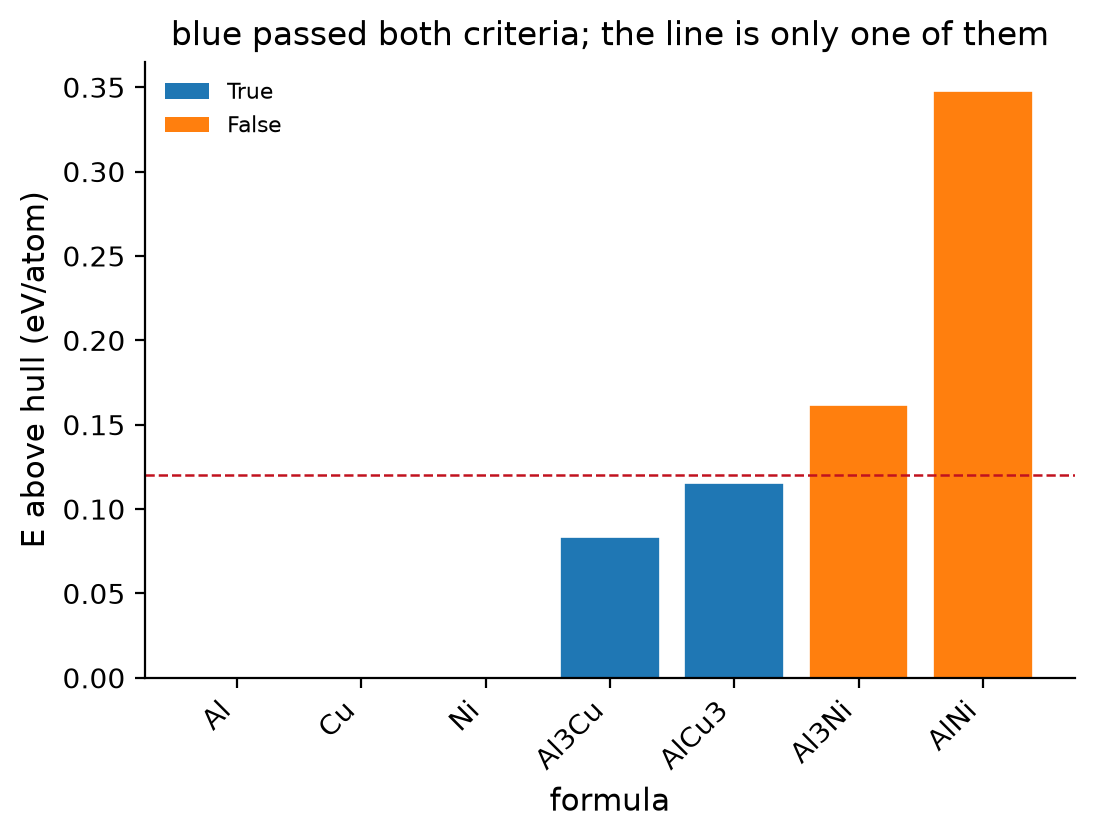

In [23]:
ax = mv.pl.scatter(md, "formula", "e_above_hull_emt", kind="bar",
                   color="passes")
ax.axhline(0.12, linestyle="--", linewidth=0.9, color="#c1121f")
ax.set_ylabel("E above hull (eV/atom)")
ax.set_title("blue passed both criteria; the line is only one of them")

Cu and Ni sit at zero and are still grey — they failed on density, not on
stability. That is the argument for depositing a boolean column instead of
returning a shorter list: the reason a candidate was dropped is a result, and a
filtered list throws it away.

The screen deposits a boolean column and the criteria that produced it. It does
**not** return a shorter list, because which criterion a candidate failed is a
result. Subset when you actually want the short list:

```python
shortlist = md[md.obs['passes']]
```

When more than one objective matters and no single column decides:

In [24]:
mv.screen.pareto(md, {"e_above_hull_emt": "min", "density": "min"})
md.obs[["formula", "e_above_hull_emt", "density", "pareto",
        "pareto_rank"]].round(4)

,formula,e_above_hull_emt,density,pareto,pareto_rank
0,Al,0.0000,2.6988,True,0.0
1,Cu,0.0000,8.9353,False,2.0
2,Ni,0.0000,8.9082,False,1.0
3,Al3Cu,0.0833,4.0448,False,1.0
4,AlCu3,0.1152,7.1341,False,2.0
5,Al3Ni,0.1616,4.2932,False,2.0
6,AlNi,0.3477,5.8940,False,3.0


`pareto_rank` keeps the second-best trade-offs reachable instead of discarding
everything that is not optimal.

When one column really does decide, `mv.screen.rank` is the simpler tool.

In [25]:
mv.screen.rank(md, by="e_above_hull_emt")
md.obs[["formula", "e_above_hull_emt", "rank"]].sort_values("rank").round(4)

,formula,e_above_hull_emt,rank
0,Al,0.0000,1.0
1,Cu,0.0000,2.0
2,Ni,0.0000,3.0
3,Al3Cu,0.0833,4.0
4,AlCu3,0.1152,5.0
5,Al3Ni,0.1616,6.0
6,AlNi,0.3477,7.0


## Is the reaction downhill?

A hull says whether a phase survives against everything in the dataset.
`mv.thermo.reaction` answers a narrower, more practical question: does *this*
combination of reactants make *that* product, and by how much.

In [26]:
mv.thermo.reaction(md, reactants=["Al", "Ni"], products=["AlNi"], level="emt")

{'reactants': ['Al', 'Ni'],
 'products': ['AlNi'],
 'level': 'emt',
 'equation': 'Al + Ni -> AlNi',
 'energy': 0.6953649398341705,
 'energy_per_atom': 0.34768246991708524,
 'favourable': False}

`favourable: False` and a positive energy — EMT again saying no intermetallic is
stable, for the reason given above. On a level of theory that can see chemical
ordering this is the number that tells you whether a synthesis route is worth
attempting.

Text(0.5, 1.0, 'stability against density')

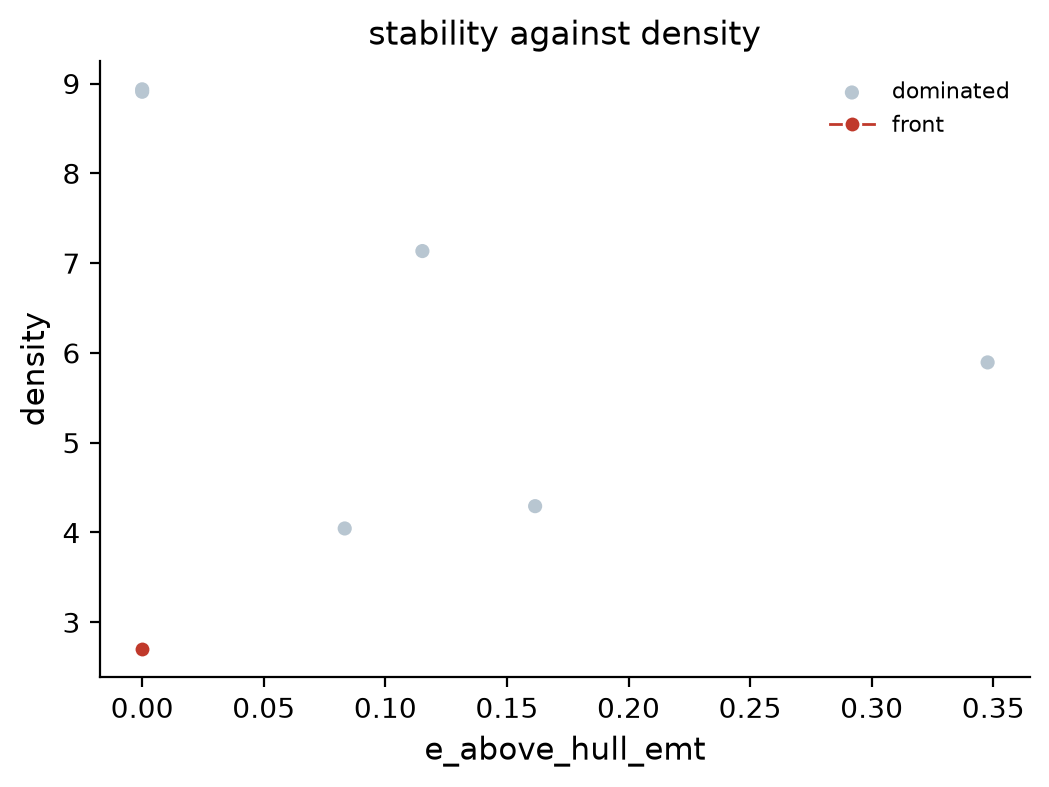

In [27]:
ax = mv.pl.pareto(md, "e_above_hull_emt", "density")
ax.set_title("stability against density")

## What the object remembers

In [28]:
for step in mv.provenance(md):
    print(step)

data.from_structures
pp.standardize(source='input', symprec=0.01)
pp.describe(source='input')
pp.qc(source='input', min_distance=0.5, require_charge_balance=False)
pp.filter_materials(flag='is_valid', n_dropped=0)
pp.dedup(source='input', symprec=0.1)
calc.relax(level='emt', source='input', fmax=0.05, cell=True, key_added='relaxed_emt')
thermo.hull(level='emt', source='relaxed_emt', n_references=0)
screen.filter(name='passes', e_above_hull_emt__lt=0.12, density__lt=8.0)
screen.pareto(name='pareto', e_above_hull_emt='min', density='min')
screen.rank(by='e_above_hull_emt', name='rank', ascending=True)
thermo.reaction(reactants=['Al', 'Ni'], products=['AlNi'], level='emt')


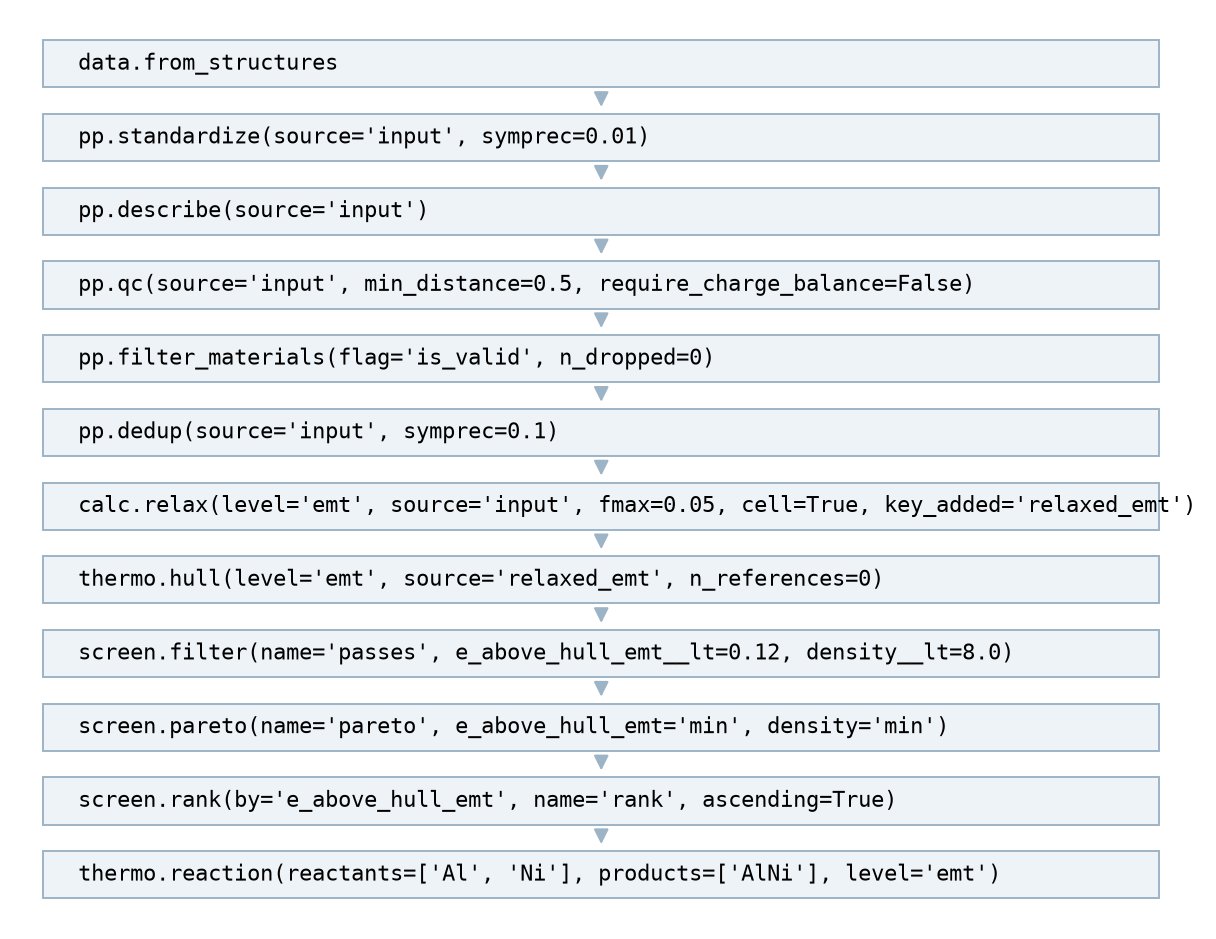

In [29]:
ax = mv.pl.provenance(md)

Parameters are recorded with each call, so the history replays as code rather
than reading as a list of verbs.

## Save it

```python
md.write_h5ad('screen.h5ad')
```

Structures, descriptors, level records and provenance all survive, and the file
is an ordinary `h5ad` that anndata can read without matverse installed.

```{seealso}
[Chemical space](chemical_space.ipynb) picks up from this object and asks what
distinguishes the candidates that passed.
```